In [3]:
# ============================================
# Install Required Libraries
# ============================================

!pip install pandas numpy matplotlib seaborn kagglehub

# ============================================
# Imports
# ============================================

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 44.6 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 43.9 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 43.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


## Business Problem

Explain the goal of the project.

Example:  
Analyze subscriber data to identify churn trends, calculate key KPIs, and create risk segments.


## Data Understanding

Describe the dataset, its source, and key features.

Example:  
The dataset contains subscriber information from a telecommunications company, including customer demographics, subscription details, and service usage.

Key features include:
- tenure
- contract type
- monthly charges
- payment method
- churn indicator

In [4]:
!pip install kagglehub
!pip install pandas

In [5]:
# ============================================
# Load Data
# ============================================

import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

files = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(files)
df.head()

Path to dataset files: /Users/shreytrivedi/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ============================================
# Inspect Dataset
# ============================================
rows, cols = df.shape
print(f"Dataset has {rows} rows and {cols} columns.")
print("Column names:", df.columns.tolist())
print("Data types:\n", df.dtypes)
print("Missing values:\n", df.isnull().sum())
print("Unique values in 'Churn':", df['Churn'].unique())
print("Value counts for 'Churn':\n", df['Churn'].value_counts())



Dataset has 7043 rows and 21 columns.
Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Missing v

In [7]:
# ============================================
# Data Cleaning
# ============================================

df_clean = df.copy()

# convert columns if needed
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

    
# handle missing values
df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)


# remove duplicates
df_clean.drop_duplicates(inplace=True)

# convert churn column to numeric
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

/var/folders/b7/433jvhln44x8gd6l9x_6tkwr0000gn/T/ipykernel_81225/1000857122.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)


In [8]:
# ============================================
# Feature Engineering
# ============================================

# create tenure buckets
df_clean["TenureBucket"] = pd.cut(df_clean["tenure"], bins=[0, 12, 24, 36, 48, 60], labels=["0-12", "13-24", "25-36", "37-48", "49-60"])

# create charge buckets
df_clean["ChargeBucket"] = pd.cut(df_clean["MonthlyCharges"], bins=5, labels=["Low", "Medium", "High", "Very High", "Extremely High"])


In [9]:
# ============================================
# KPI Calculation
# ============================================

# total customers
total_customers = len(df_clean)
# churn rate
churn_rate = df_clean["Churn"].mean()

# retention rate
retention_rate = 1 - churn_rate
# average revenue per user
avg_revenue_per_user = df_clean["MonthlyCharges"].mean()
# average tenure
avg_tenure = df_clean["tenure"].mean()

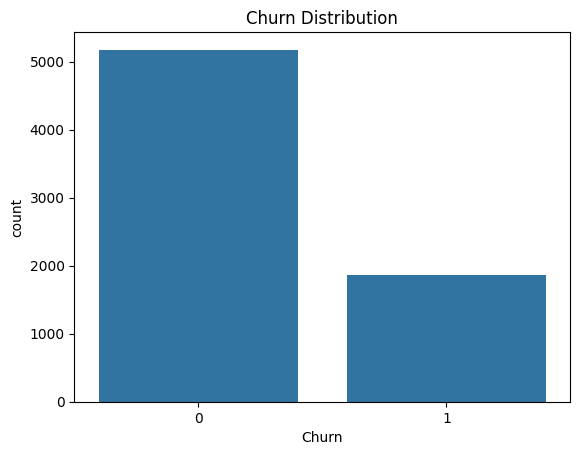

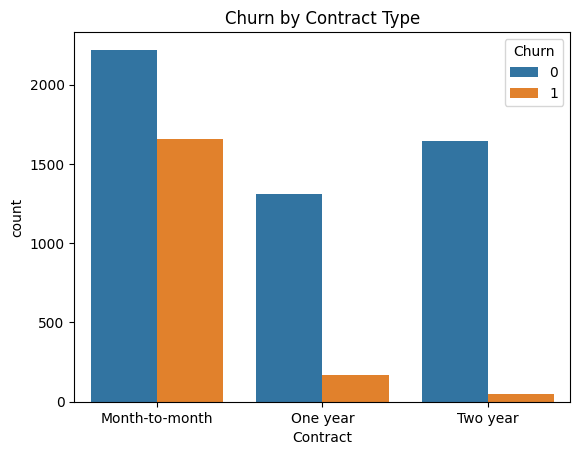

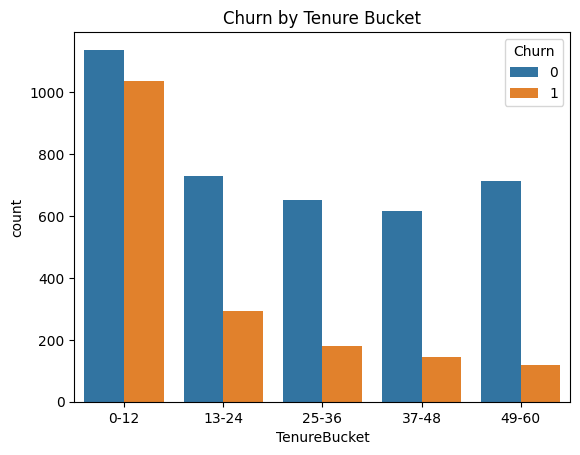

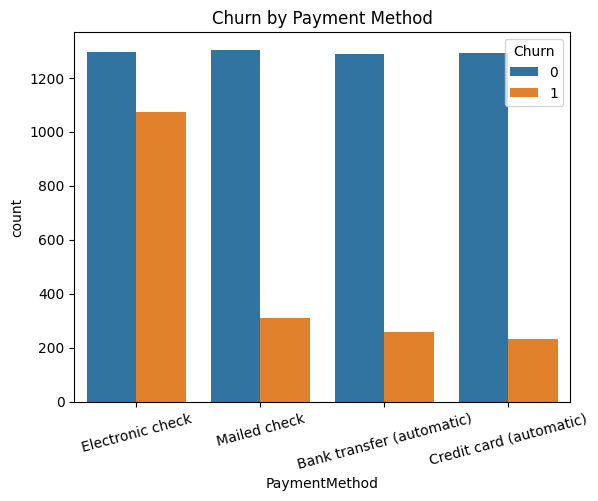

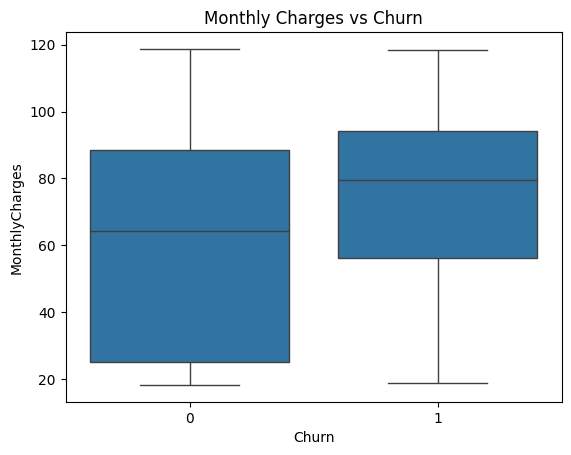

In [10]:
# ============================================
# Exploratory Data Analysis
# ============================================

# churn distribution plot
sns.countplot(x="Churn", data=df_clean)
plt.title("Churn Distribution")
plt.show()

# churn by contract
sns.countplot(x="Contract", hue="Churn", data=df_clean)
plt.title("Churn by Contract Type")
plt.show()

# churn by tenure
sns.countplot(x="TenureBucket", hue="Churn", data=df_clean)
plt.title("Churn by Tenure Bucket")
plt.show()

# churn by payment method
sns.countplot(x="PaymentMethod", hue="Churn", data=df_clean)
plt.title("Churn by Payment Method")
plt.xticks(rotation=15)
plt.show()

# charges vs churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_clean)
plt.title("Monthly Charges vs Churn")
plt.show()


In [11]:
# ============================================
# Segment Analysis
# ============================================

# churn by contract
churn_by_contract = df_clean.groupby("Contract")["Churn"].mean()
print("Churn Rate by Contract:")
print(churn_by_contract)

# churn by tenure group
churn_by_tenure = df_clean.groupby("TenureBucket")["Churn"].mean()
print("\nChurn Rate by Tenure Bucket:")
print(churn_by_tenure)

# churn by payment method
churn_by_payment = df_clean.groupby("PaymentMethod")["Churn"].mean()
print("\nChurn Rate by Payment Method:")
print(churn_by_payment)

# churn by charge bucket
churn_by_charge = df_clean.groupby("ChargeBucket")["Churn"].mean()
print("\nChurn Rate by Charge Bucket:")
print(churn_by_charge)

Churn Rate by Contract:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn Rate by Tenure Bucket:
TenureBucket
0-12     0.476782
13-24    0.287109
25-36    0.216346
37-48    0.190289
49-60    0.144231
Name: Churn, dtype: float64

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

Churn Rate by Charge Bucket:
ChargeBucket
Low               0.114079
Medium            0.269652
High              0.294806
Very High         0.369660
Extremely High    0.300573
Name: Churn, dtype: float64


In [12]:
# ============================================
# Risk Segmentation
# ============================================

def assign_risk(row):
    # define rules for high / medium / low risk
    if row["Contract"] == "Month-to-month" and row["tenure"] < 12:
        return "High Risk"
    elif row["tenure"] < 24:
        return "Medium Risk"
    else:
        return "Low Risk"

df_clean["risk_segment"] = df_clean.apply(assign_risk, axis=1)

df_clean["risk_segment"].value_counts()

risk_segment
Low Risk       3927
High Risk      1908
Medium Risk    1208
Name: count, dtype: int64

## Key Insights

- Customers on **month-to-month contracts have the highest churn rate** compared to longer-term contracts.
- Customers with **low tenure (new customers)** are significantly more likely to churn.
- Customers paying **higher monthly charges tend to churn more frequently** than those on lower-cost plans.
- Customers using **electronic check payment methods show higher churn rates** than automatic payment methods.

In [13]:
# ============================================
# Export Processed Dataset
# ============================================

output_path = "../data/processed/churn_cleaned.csv"

df_clean.to_csv(output_path, index=False)

In [14]:
# Subscriber Churn Analysis

## 1. Business Problem
## 2. Load Dataset
## 3. Data Inspection
## 4. Data Cleaning
## 5. Feature Engineering
## 6. KPI Calculation
## 7. Exploratory Analysis
## 8. Segment Analysis
## 9. Risk Segmentation
## 10. Insights
## 11. Export Data